In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
df1 = pd.read_csv("Year_2009_2010_Cleaned.csv")
df2 = pd.read_csv("Year_2010_2011_Cleaned.csv")

In [5]:
df = pd.concat([df1, df2], ignore_index=True)

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Segment,Sales_Channel,Payment_Mode,Order_Priority,Unnamed: 12
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Regular,Online,UPI,High,NaN
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Regular,Online,UPI,Low,NaN
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Premium,Offline,Card,Medium,NaN
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,New,Retail,Cash,Low,NaN
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Regular,Online,Net Banking,High,NaN


In [7]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Customer_Segment', 'Sales_Channel',
       'Payment_Mode', 'Order_Priority', 'Unnamed: 12'],
      dtype='str')


In [11]:
df["InvoiceDate"].head(20)

0     2009-12-01 07:45:00
1     2009-12-01 07:45:00
2     2009-12-01 07:45:00
3     2009-12-01 07:45:00
4     2009-12-01 07:45:00
5     2009-12-01 07:45:00
6     2009-12-01 07:45:00
7     2009-12-01 07:45:00
8     2009-12-01 07:46:00
9     2009-12-01 07:46:00
10    2009-12-01 07:46:00
11    2009-12-01 07:46:00
12    2009-12-01 09:06:00
13    2009-12-01 09:06:00
14    2009-12-01 09:06:00
15    2009-12-01 09:06:00
16    2009-12-01 09:06:00
17    2009-12-01 09:06:00
18    2009-12-01 09:06:00
19    2009-12-01 09:06:00
Name: InvoiceDate, dtype: str

In [12]:
df["InvoiceDate"].dtype

<StringDtype(na_value=nan)>

In [13]:
df["InvoiceDate"].sample(10)

933390       05-12-2011 14.29
43111     2010-01-21 13:33:00
579784       03-05-2011 11.22
443874       17-12-2010 17.08
65321     2010-02-16 15:55:00
510190       27-02-2011 13.47
555259       07-04-2011 11.16
20433     2009-12-13 13:31:00
81898     2010-03-05 16:02:00
11064     2009-12-07 08:13:00
Name: InvoiceDate, dtype: str

In [15]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"].str.replace(".", ":", regex=False),
    dayfirst=True,
    errors="coerce"
)

In [16]:
monthly_sales = df.groupby(
    df["InvoiceDate"].dt.to_period("M")
)["Quantity"].sum().reset_index()

In [17]:
monthly_sales["InvoiceDate"] = monthly_sales["InvoiceDate"].dt.to_timestamp()

In [18]:
monthly_sales.head()

,InvoiceDate,Quantity
0,2009-01-01,24403
1,2009-02-01,29751
2,2009-03-01,48032
3,2009-04-01,20057
4,2009-05-01,5119


In [19]:
monthly_sales["Month"] = range(len(monthly_sales))

monthly_sales.head()

,InvoiceDate,Quantity,Month
0,2009-01-01,24403,0
1,2009-02-01,29751,1
2,2009-03-01,48032,2
3,2009-04-01,20057,3
4,2009-05-01,5119,4


In [20]:
X = monthly_sales[["Month"]]

y = monthly_sales["Quantity"]

In [21]:
model = LinearRegression()

model.fit(X, y)

print("Model trained")

Model trained


In [22]:
monthly_sales["Forecast"] = model.predict(X)

monthly_sales.head()

,InvoiceDate,Quantity,Month,Forecast
0,2009-01-01,24403,0,-9625.108696
1,2009-02-01,29751,1,116.644269
2,2009-03-01,48032,2,9858.397233
3,2009-04-01,20057,3,19600.150198
4,2009-05-01,5119,4,29341.903162


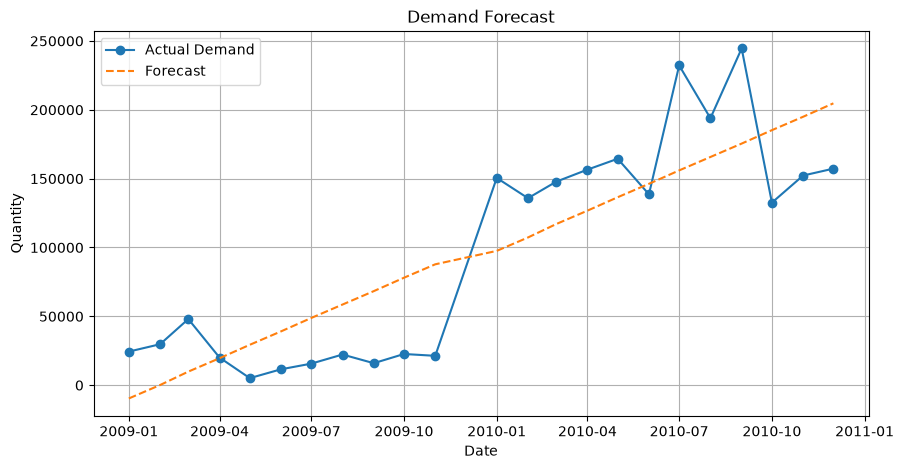

In [23]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Quantity"],
    label="Actual Demand",
    marker="o"
)

plt.plot(
    monthly_sales["InvoiceDate"],
    monthly_sales["Forecast"],
    label="Forecast",
    linestyle="--"
)

plt.title("Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Quantity")

plt.legend()
plt.grid()

plt.show()

In [24]:
future = pd.DataFrame({
    "Month": range(
        len(monthly_sales),
        len(monthly_sales)+6
    )
})

future

,Month
0,23
1,24
2,25
3,26
4,27
5,28


In [25]:
future["Forecast"] = model.predict(
    future[["Month"]]
)

future

,Month,Forecast
0,23,214435.209486
1,24,224176.962451
2,25,233918.715415
3,26,243660.468379
4,27,253402.221344
5,28,263143.974308


In [26]:
future["Normal Demand"] = future["Forecast"]

In [27]:
future["High Demand"] = future["Forecast"] * 1.20

In [28]:
future["Low Demand"] = future["Forecast"] * 0.80

In [29]:
future

,Month,Forecast,Normal Demand,High Demand,Low Demand
0,23,214435.209486,214435.209486,257322.251383,171548.167589
1,24,224176.962451,224176.962451,269012.354941,179341.569960
2,25,233918.715415,233918.715415,280702.458498,187134.972332
3,26,243660.468379,243660.468379,292392.562055,194928.374704
4,27,253402.221344,253402.221344,304082.665613,202721.777075
5,28,263143.974308,263143.974308,315772.769170,210515.179447


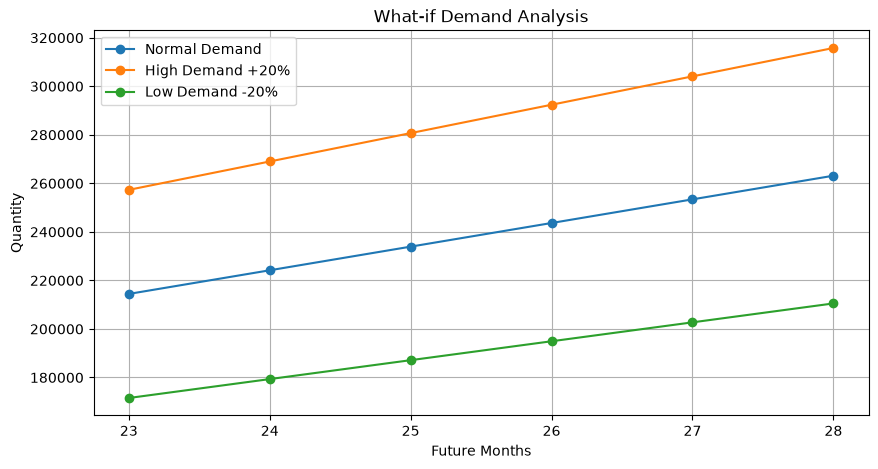

In [30]:
plt.figure(figsize=(10,5))

plt.plot(
    future["Month"],
    future["Normal Demand"],
    marker="o",
    label="Normal Demand"
)

plt.plot(
    future["Month"],
    future["High Demand"],
    marker="o",
    label="High Demand +20%"
)

plt.plot(
    future["Month"],
    future["Low Demand"],
    marker="o",
    label="Low Demand -20%"
)

plt.title("What-if Demand Analysis")

plt.xlabel("Future Months")

plt.ylabel("Quantity")

plt.legend()

plt.grid()

plt.show()

In [31]:
future.to_excel(
    "Demand_Forecast_WhatIf.xlsx",
    index=False
)

print("Saved Successfully")

Saved Successfully
